# Response Analysis – All Wave Headings

Computes RAOs, response spectra, and most-probable-maximum responses for wave
headings 0°, 45°, 90°, 135°, and 180° using the WAMIT data in `WAMIT_Results/`
(48 frequency points, 0.30–2.65 rad/s).

In [ ]:
import os
import sys
from pathlib import Path

# Resolve this notebook's folder (works in VS Code and standard Jupyter)
NOTEBOOK_DIR = Path(globals().get('__vsc_ipynb_file__', Path.cwd() / '_')).parent
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))
from thesis_style import apply, full, FULL_WIDTH, save
apply()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Paths

In [ ]:
WAMIT_ROOT = str(NOTEBOOK_DIR / "WAMIT_Results")

## Added Mass and Radiation Damping

In [3]:
# (file-name suffix, row i, col j) — the 18 non-zero entries of the 6×6 matrices
AM_ENTRIES = [
    ("surge",        0, 0), ("surge_heave",  0, 2), ("surge_pitch",  0, 4),
    ("sway",         1, 1), ("sway_roll",    1, 3), ("sway_yaw",     1, 5),
    ("heave",        2, 2), ("heave_surge",  2, 0), ("heave_pitch",  2, 4),
    ("roll",         3, 3), ("roll_sway",    3, 1), ("roll_yaw",     3, 5),
    ("pitch",        4, 4), ("pitch_surge",  4, 0), ("pitch_heave",  4, 2),
    ("yaw",          5, 5), ("yaw_sway",     5, 1), ("yaw_roll",     5, 3),
]

_ref  = pd.read_csv(os.path.join(WAMIT_ROOT, "AddedMass", "Added mass 1_surge.csv"),
                    sep=";", skiprows=1)
omega = _ref.iloc[:, 0].to_numpy()
N     = len(omega)

A_tensor = np.zeros((N, 6, 6))
B_tensor = np.zeros((N, 6, 6))

for suffix, i, j in AM_ENTRIES:
    df_a = pd.read_csv(
        os.path.join(WAMIT_ROOT, "AddedMass", f"Added mass 1_{suffix}.csv"),
        sep=";", skiprows=1)
    df_b = pd.read_csv(
        os.path.join(WAMIT_ROOT, "Damping", f"Radiation damping 1_{suffix}.csv"),
        sep=";", skiprows=1)
    A_tensor[:, i, j] = df_a.iloc[:, 1].to_numpy()
    B_tensor[:, i, j] = df_b.iloc[:, 1].to_numpy()

print(f"Frequency range: {omega[0]:.3f} – {omega[-1]:.3f} rad/s  ({N} points)")

Frequency range: 0.300 – 2.650 rad/s  (48 points)


## Excitation Forces for All Headings

In [4]:
DOF_NAMES = ["surge", "sway", "heave", "roll", "pitch", "yaw"]

# display label -> (subfolder, heading tag used in the file names)
HEADINGS = {
    "0°":   ("0deg",   "0"),
    "45°":  ("45deg",  "45"),
    "90°":  ("90deg",  "90"),
    "135°": ("135deg", "135"),
    "180°": ("180deg", "180"),
}

F_all = {}
for label, (folder, hdg) in HEADINGS.items():
    mag_list, pha_list = [], []
    for dof in DOF_NAMES:
        mag_f = os.path.join(WAMIT_ROOT, folder, "Fexc",
                             f"Excitation Force 1_{dof} heading {hdg}_0o mag.csv")
        pha_f = os.path.join(WAMIT_ROOT, folder, "FexcPha",
                             f"Excitation Force 1_{dof} heading {hdg}_0o phase.csv")
        mag_list.append(pd.read_csv(mag_f, sep=";", skiprows=1).iloc[:, 1].to_numpy())
        pha_list.append(pd.read_csv(pha_f, sep=";", skiprows=1).iloc[:, 1].to_numpy())
    F_mag = np.column_stack(mag_list)           # (N, 6)  magnitudes [N/m]
    F_pha = np.column_stack(pha_list)           # (N, 6)  phases [rad]
    F_all[label] = F_mag * np.exp(1j * F_pha)  # (N, 6)  complex

print("Excitation forces loaded for headings:", list(F_all.keys()))

Excitation forces loaded for headings: ['0°', '45°', '90°', '135°', '180°']


## Structural Matrices

Mass matrix, hydrostatic stiffness, mooring stiffness, and linearised fender stiffness.

In [5]:
# Hydrostatic stiffness
C_hs = np.array([[0, 0,    0,     0,      0,      0],
                 [0, 0,    0,     0,      0,      0],
                 [0, 0,  8.2e7,   0,    8.9e8,    0],
                 [0, 0,    0,   4.0e9,    0,      0],
                 [0, 0,  8.9e8,   0,   3.6e11,    0],
                 [0, 0,    0,     0,      0,      0]])

# Mooring stiffness
C_moor = np.array([
    [ 4.33903e+05, -7.49583e+03,  3.74792e+03,  1.12437e+05,  1.09746e+06, -2.52720e+06],
    [-7.49583e+03,  7.05115e+05, -8.78774e+04, -5.30908e+06, -2.37827e+05, -1.59016e+06],
    [ 3.74792e+03, -8.78774e+04,  2.48229e+04,  8.44792e+05,  3.02761e+04,  1.25389e+05],
    [ 1.12437e+05, -5.30908e+06,  8.44792e+05,  4.40404e+07,  1.94995e+06,  1.17124e+07],
    [ 1.09746e+06, -2.37827e+05,  3.02761e+04,  1.94995e+06,  2.34569e+08,  9.56906e+08],
    [-2.52720e+06, -1.59016e+06,  1.25389e+05,  1.17124e+07,  9.56906e+08,  8.46265e+09],
])


# Vessel inertia
rho     = 1025.0
V_ship  = 82520.1
m       = rho * V_ship
L_ship  = 250.0
B_ship  = 36.0
cg      = [-4.8, 0.0, 3.0]

k_phi   = 0.35 * B_ship      # roll radius of gyration
k_theta = 0.25 * L_ship      # pitch radius of gyration (ITTC)
k_psi   = 0.25 * L_ship      # yaw radius of gyration

Mzg = m * cg[2]
I4  = m * k_phi**2
I46 = m * cg[0] * cg[2]
I5  = m * k_theta**2
I6  = m * k_psi**2

M_mat = np.array([
    [m,    0,    0,     0,   Mzg,    0 ],
    [0,    m,    0,  -Mzg,    0,     0 ],
    [0,    0,    m,     0,    0,     0 ],
    [0,  -Mzg,  0,    I4,    0,   -I46],
    [Mzg,  0,   0,     0,   I5,     0 ],
    [0,    0,   0,  -I46,    0,    I6 ],
])

# Fender stiffness (6 fenders in 3 symmetric pairs at x = ±10, ±30, ±50 m)
fender_dist  = np.array([0.0, -0.25, -0.5, -0.75, -0.95, -1.05,
                         -1.25, -1.5, -1.75, -1.95, -2.05, -2.25, -2.5])  # [m]
fender_force = np.array([0.0, 8.1818e5, 1.2424e6, 1.3939e6, 1.272e6, 1.272e6,
                         1.6205e6, 2.0e6, 1.9303e6, 1.8083e6, 1.8083e6,
                         2.8227e6, 5.053e6])                               # [N]
n_fenders    = 6
delta_single = 0.03            # compression per fender [m]
delta_op     = delta_single    # operating deflection per fender [m]
F_op         = np.interp(delta_op, np.abs(fender_dist), fender_force)
k_fender     = F_op / delta_op

x_arms   = [10.0, 30.0, 50.0]  # longitudinal arm positions [m]
C_fender = np.zeros((6, 6))
C_fender[1, 1] = n_fenders * k_fender
C_fender[5, 5] = 2 * k_fender * sum(x**2 for x in x_arms)

C_tot = C_hs + C_moor + C_fender

print(f"Mass            : {m:.4e} kg")
print(f"Fender stiffness: {k_fender:.4e} N/m")

Mass            : 8.4583e+07 kg
Fender stiffness: 3.2727e+06 N/m


## RAO Computation

Solves $\mathbf{Z}(\omega)\,\mathbf{x} = \mathbf{F}$ for each frequency and heading,
where $\mathbf{Z} = -\omega^2(\mathbf{M}+\mathbf{A}) + i\omega\mathbf{B} + \mathbf{C}$.

In [6]:
DOF_LABELS = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]
UNITS_RAO  = ["m/m",   "m/m",  "m/m",   "deg/m", "deg/m", "deg/m"]
UNITS_RESP = ["m",     "m",    "m",     "deg",   "deg",   "deg"]
r2d        = np.array([1, 1, 1, 180/np.pi, 180/np.pi, 180/np.pi])

results = {}
for label, F_vec in F_all.items():
    RAO = np.zeros((N, 6), dtype=complex)
    for k, w in enumerate(omega):
        Z      = -w**2 * (M_mat + A_tensor[k]) + 1j * w * B_tensor[k] + C_tot
        RAO[k] = np.linalg.solve(Z, F_vec[k])
    results[label] = dict(RAO=RAO)

print("Computed headings:", list(results.keys()))

Computed headings: ['0°', '45°', '90°', '135°', '180°']


## RAO – Response Amplitude Operator

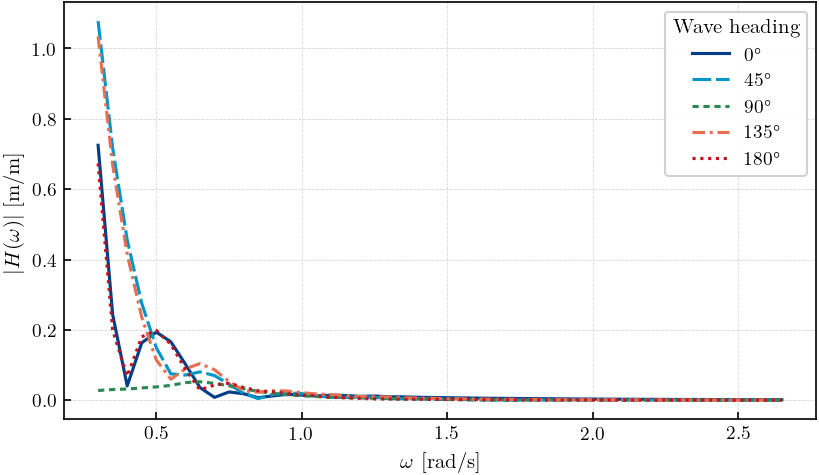

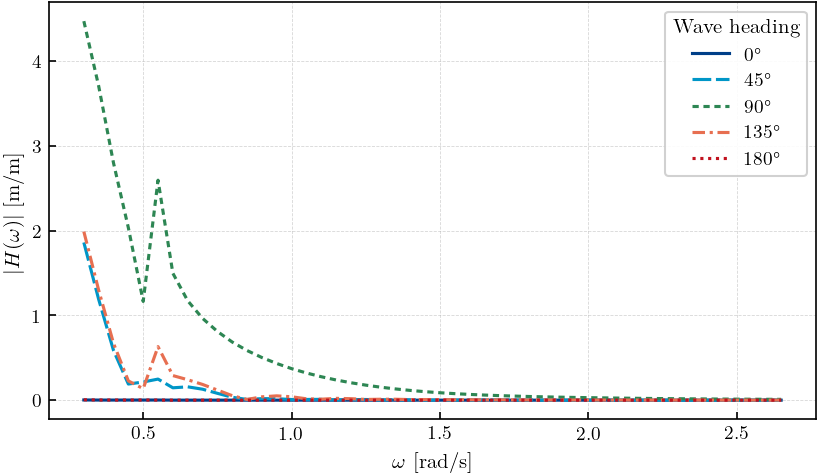

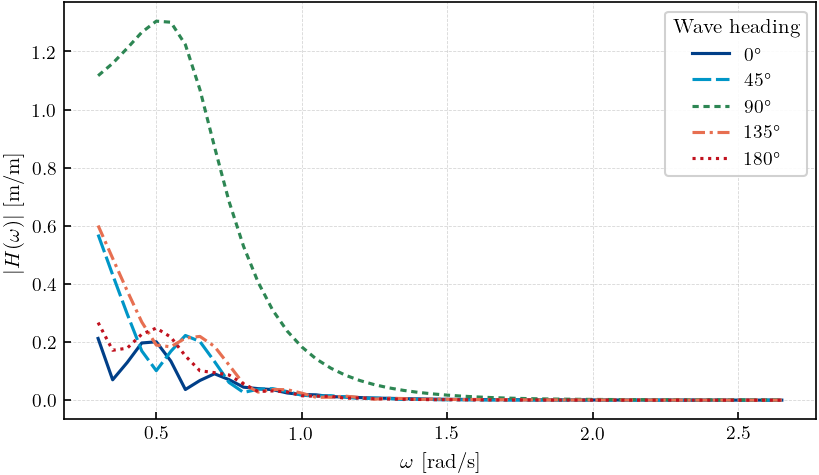

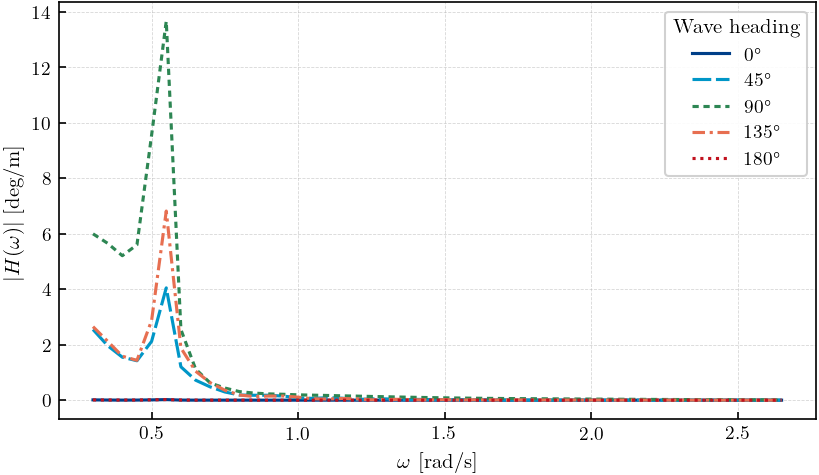

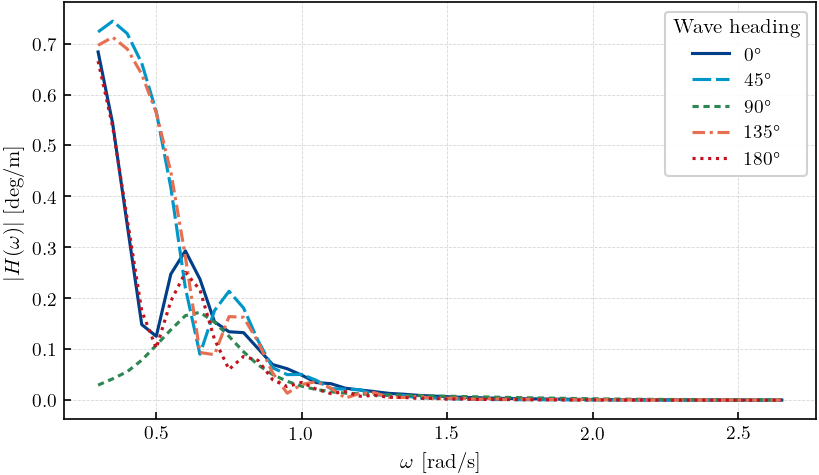

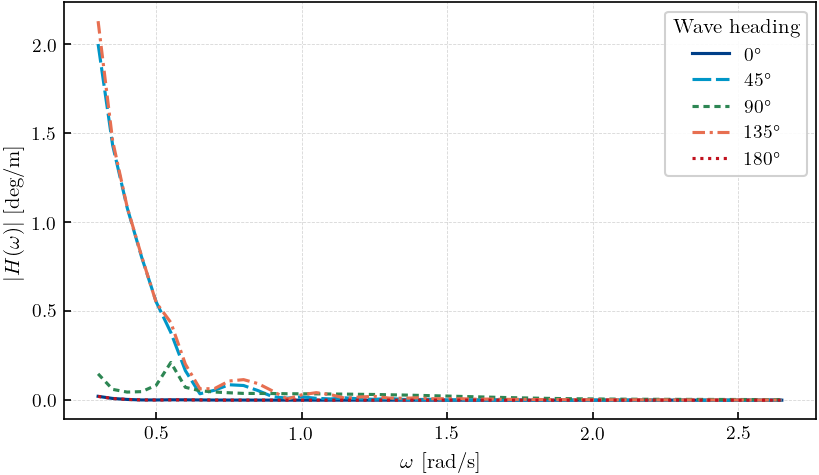

In [7]:
# Cold-to-warm heading progression: all high-contrast on white, no purple
COLORS = {
    "0°":   "#003f88",            # deep navy
    "45°":  "#0096c7",            # sky blue
    "90°":  "#2d8653",            # forest green
    "135°": "#e76f51",            # coral orange
    "180°": "#c1121f",            # deep red
}
# Explicit dash patterns — avoids thin ":" and cluttered "-."
LS = {
    "0°":   "-",                        # solid
    "45°":  (0, (6, 1.5)),              # long dash
    "90°":  (0, (2, 1.5)),              # short dash
    "135°": (0, (4, 1.5, 1, 1.5)),     # dash-dot
    "180°": (0, (1, 1.5)),              # dotted
}

for j in range(6):
    fig, ax = plt.subplots(figsize=full())
    for label, res in results.items():
        ax.plot(omega, np.abs(res["RAO"][:, j]) * r2d[j],
                color=COLORS[label], ls=LS[label], lw=1.5, label=label)
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(rf"$\lvert H(\omega) \rvert$ [{UNITS_RAO[j]}]")
    ax.legend(title="Wave heading")
    plt.tight_layout()
    save(fig, f"RAO_{DOF_LABELS[j].lower()}")
    plt.show()

## Regular Wave Response – Airy Theory

For a regular (monochromatic) Airy wave the response amplitude is:
$$\hat{x}_j = |H_j(\omega_p)| \cdot \frac{H_s}{2}, \qquad \omega_p = \frac{2\pi}{T_p}$$
Peak periods follow a constant deep-water wave steepness $S = H/L$ calibrated to
the HL29 sea-state table (1/29), giving $T_p \propto \sqrt{H_s}$.

In [8]:
g = 9.81  # [m/s²]

Hs_reg = np.array([0.50, 0.83, 1.17, 1.50, 1.83, 2.17, 2.50, 2.83, 3.17])  # [m]

# Steepness calibrated so that Hs = 1.17 m gives Tp = 4.66 s (HL29 condition 3)
# Deep-water Airy: L = gT²/(2π)  →  S = H/L = 2πH/(gT²)  →  T = sqrt(2πH/(gS))
S_steep   = 2*np.pi * 1.17 / (g * 4.66**2)          # S = 1/29
Tp_reg    = np.sqrt(2*np.pi * Hs_reg / (g * S_steep))  # [s]
omega_reg = 2*np.pi / Tp_reg                           # [rad/s]

print(f"Wave steepness: H/L = 1/{1/S_steep:.1f}  (deep-water Airy)")
print()
print(f"{'Hs [m]':>8}  {'Tp [s]':>8}  {'omega [rad/s]':>14}")
for hs, tp, w in zip(Hs_reg, Tp_reg, omega_reg):
    print(f"{hs:>8.2f}  {tp:>8.2f}  {w:>14.3f}")

Wave steepness: H/L = 1/29.0  (deep-water Airy)

  Hs [m]    Tp [s]   omega [rad/s]
    0.50      3.05           2.063
    0.83      3.92           1.601
    1.17      4.66           1.348
    1.50      5.28           1.191
    1.83      5.83           1.078
    2.17      6.35           0.990
    2.50      6.81           0.922
    2.83      7.25           0.867
    3.17      7.67           0.819


In [9]:
# Interpolate |RAO| to each wave frequency, then scale by wave amplitude Hs/2
reg_amp = {}  # label -> (n_cond, 6) array in display units [m or deg]
for label, res in results.items():
    amp = np.zeros((len(Hs_reg), 6))
    for j in range(6):
        rao_j  = np.abs(res["RAO"][:, j])
        amp[:, j] = np.interp(omega_reg, omega, rao_j) * (Hs_reg / 2) * r2d[j]
    reg_amp[label] = amp

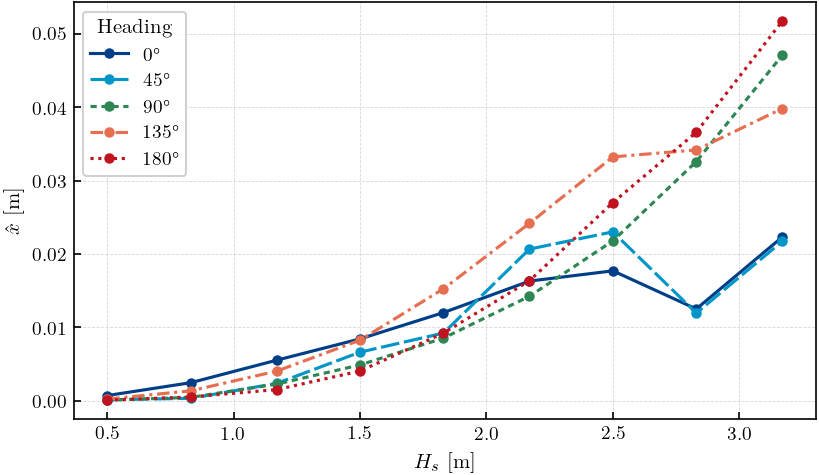

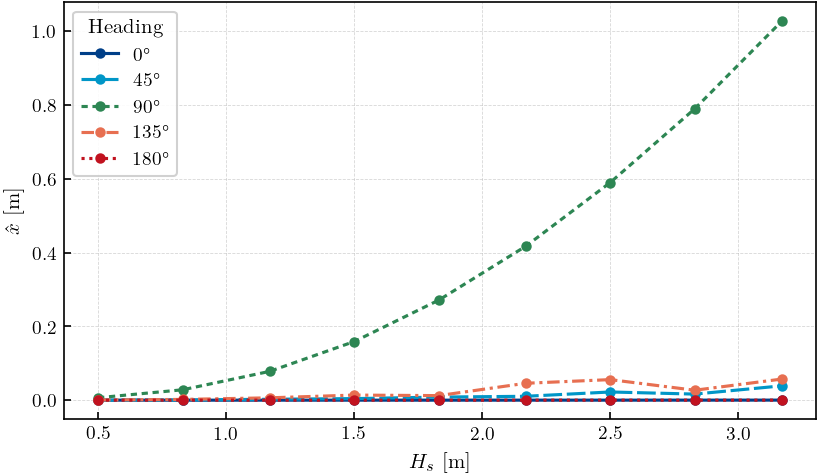

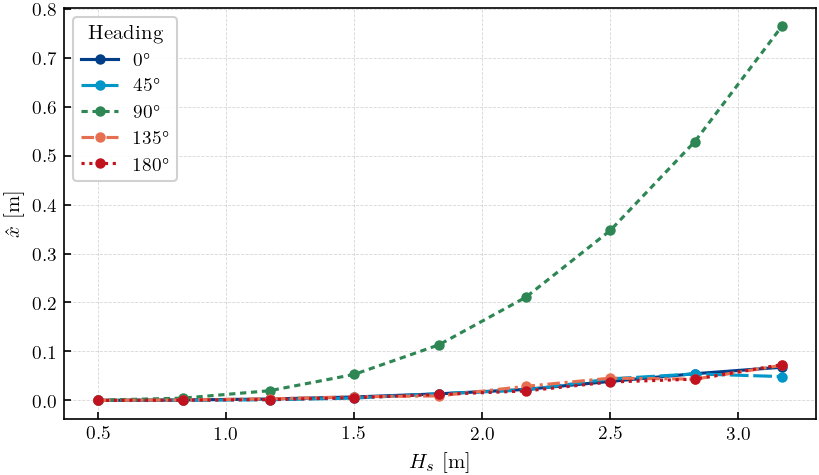

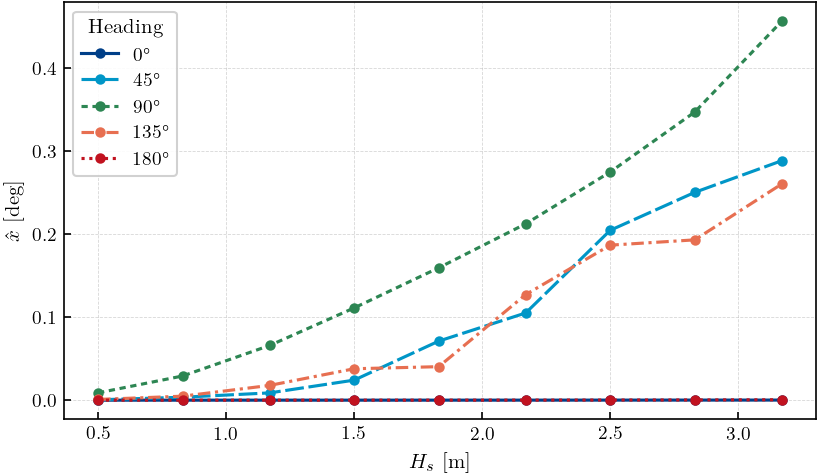

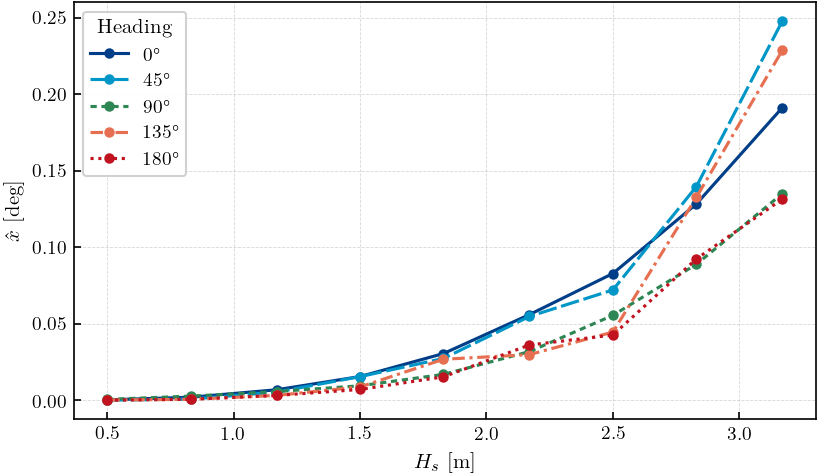

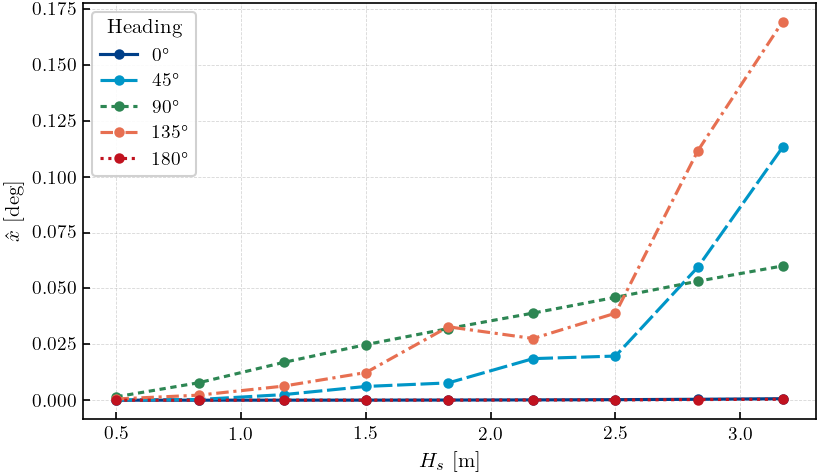

In [10]:
for j in range(6):
    fig, ax = plt.subplots(figsize=full())
    for label in results:
        ax.plot(Hs_reg, reg_amp[label][:, j],
                color=COLORS[label], ls=LS[label], lw=1.5,
                marker="o", ms=4, label=label)
    ax.set_xlabel("$H_s$ [m]")
    ax.set_ylabel(f"$\\hat{{x}}$ [{UNITS_RESP[j]}]")
    ax.legend(title="Heading")
    plt.tight_layout()
    save(fig, f"regular_response_{DOF_LABELS[j].lower()}")
    plt.show()

In [11]:
for j, dof in enumerate(DOF_LABELS):
    cols = {label: reg_amp[label][:, j] for label in results}
    df = pd.DataFrame(cols,
                      index=pd.Index([f"{hs:.2f}" for hs in Hs_reg], name="Hs [m]"))
    df.columns.name = "Heading"
    print(f"\n{dof}  [{UNITS_RESP[j]}]")
    print(df.to_string(float_format="{:.4f}".format))


Surge  [m]
Heading     0°    45°    90°   135°   180°
Hs [m]                                    
0.50    0.0007 0.0001 0.0001 0.0002 0.0001
0.83    0.0025 0.0003 0.0005 0.0014 0.0005
1.17    0.0055 0.0024 0.0023 0.0041 0.0015
1.50    0.0084 0.0066 0.0049 0.0083 0.0041
1.83    0.0120 0.0092 0.0086 0.0153 0.0092
2.17    0.0163 0.0207 0.0143 0.0242 0.0164
2.50    0.0177 0.0230 0.0218 0.0333 0.0270
2.83    0.0125 0.0120 0.0326 0.0342 0.0366
3.17    0.0223 0.0217 0.0471 0.0398 0.0518

Sway  [m]
Heading     0°    45°    90°   135°   180°
Hs [m]                                    
0.50    0.0000 0.0000 0.0066 0.0004 0.0000
0.83    0.0000 0.0004 0.0281 0.0020 0.0000
1.17    0.0000 0.0025 0.0780 0.0064 0.0000
1.50    0.0000 0.0042 0.1588 0.0138 0.0000
1.83    0.0000 0.0084 0.2710 0.0123 0.0000
2.17    0.0000 0.0105 0.4171 0.0458 0.0000
2.50    0.0001 0.0222 0.5897 0.0557 0.0000
2.83    0.0001 0.0165 0.7896 0.0269 0.0000
3.17    0.0001 0.0388 1.0270 0.0572 0.0001

Heave  [m]
Heading     0°    4

## Irregular Wave Response – JONSWAP Spectrum

For each sea state $(H_s, T_p)$ the one-sided JONSWAP spectrum ($\gamma = 3.3$) is
evaluated on the WAMIT frequency grid.  The response spectrum
$S_x(\omega) = |H_j(\omega)|^2\,S_\eta(\omega)$ gives spectral moments from which
the significant response $x_{1/3} = 4\sqrt{m_0}$ and the most-probable-maximum
(MPM) over a 3-hour storm are derived (Rayleigh assumption):
$$\text{MPM} = \sqrt{2m_0}\,\sqrt{\ln N_z}, \qquad N_z = \frac{T_\text{storm}}{T_z}$$

In [12]:
T_storm = 3 * 3600  # storm duration [s]

def jonswap(omega, Hs, Tp, gamma=3.3):
    wp  = 2*np.pi / Tp
    sig = np.where(omega <= wp, 0.07, 0.09)
    r   = np.exp(-(omega - wp)**2 / (2 * sig**2 * wp**2))
    S   = omega**(-5) * np.exp(-1.25 * (wp / omega)**4) * gamma**r
    m0  = np.trapezoid(S, omega)
    return S * Hs**2 / (16 * m0)

# JONSWAP spectrum for each of the 9 (Hs, Tp) conditions on the WAMIT omega grid
S_wave = np.array([jonswap(omega, hs, tp) for hs, tp in zip(Hs_reg, Tp_reg)])

irr_mpm = {}  # label -> (n_cond, 6) MPM [display units]

for label, res in results.items():
    mpm_arr = np.zeros((len(Hs_reg), 6))
    for i in range(len(Hs_reg)):
        Sw = S_wave[i]
        for j in range(6):
            H2            = np.abs(res["RAO"][:, j])**2
            Sx            = H2 * Sw
            m0            = np.trapezoid(Sx, omega)
            m2            = np.trapezoid(omega**2 * Sx, omega)
            Tz            = 2*np.pi * np.sqrt(m0 / m2)
            Nz            = T_storm / Tz
            mpm_arr[i, j] = np.sqrt(2 * m0) * np.sqrt(np.log(Nz)) * r2d[j]
    irr_mpm[label] = mpm_arr

print("JONSWAP irregular wave analysis complete.")

JONSWAP irregular wave analysis complete.


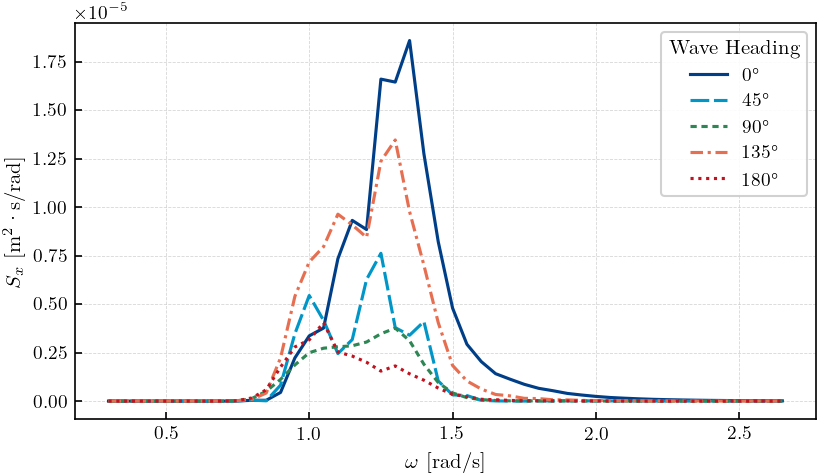

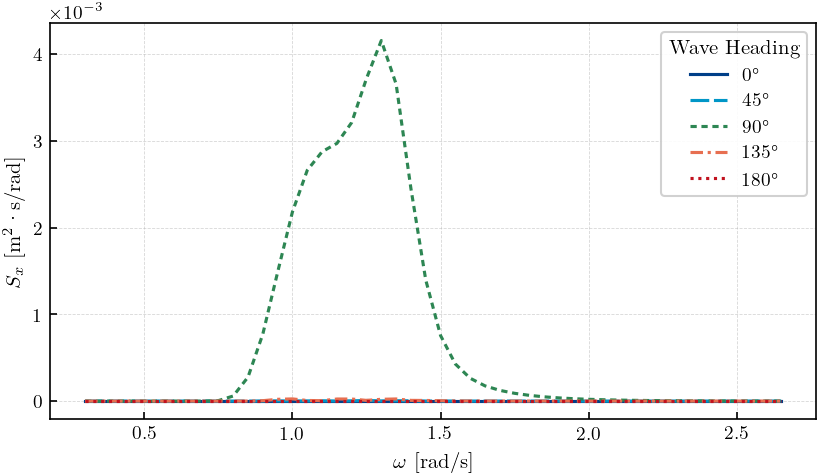

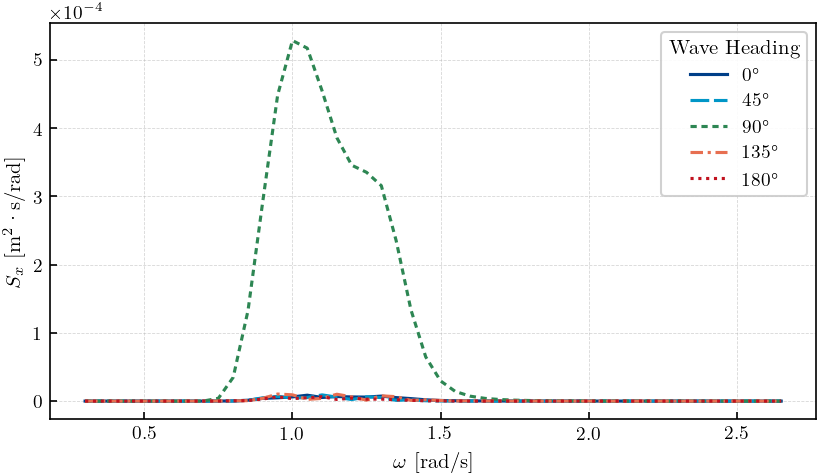

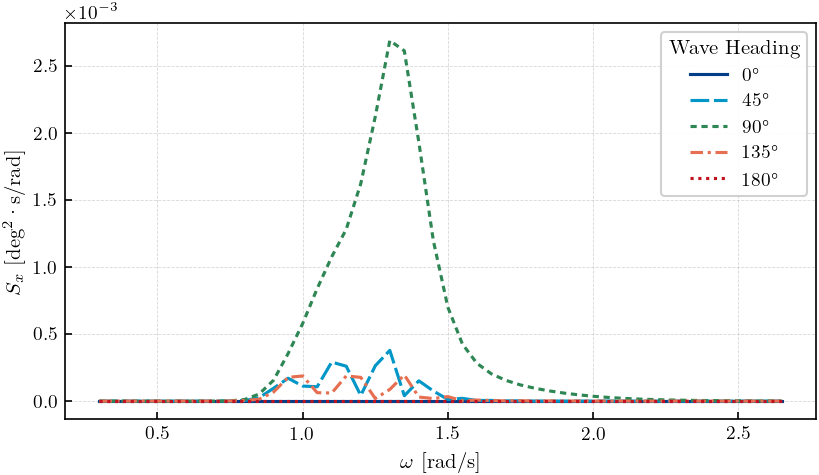

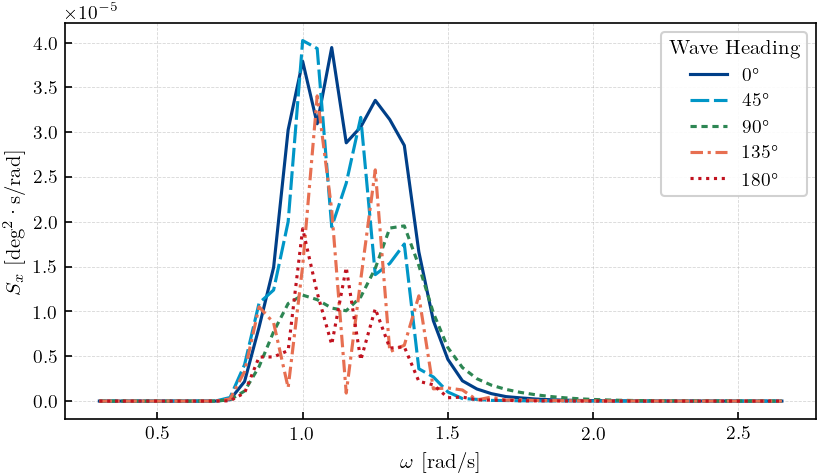

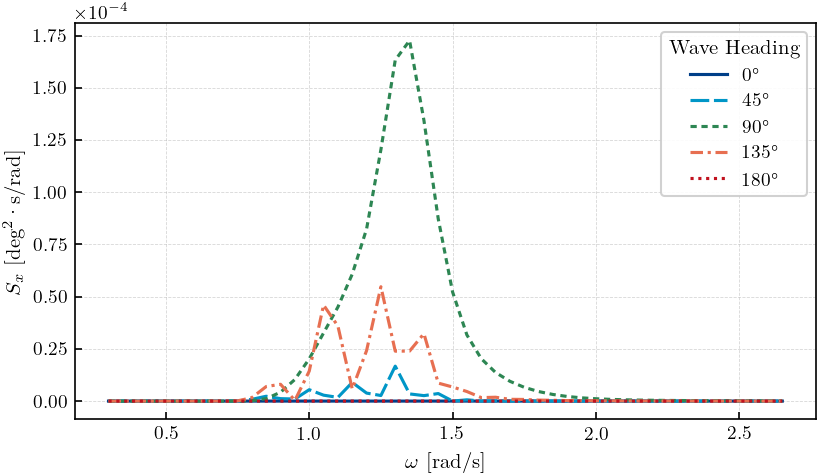

In [13]:
ref_idx = np.argmin(np.abs(Hs_reg - 1.17))  # reference condition (Hs ≈ 1.17 m)

for j in range(6):
    fig, ax = plt.subplots(figsize=full())
    for label, res in results.items():
        H2 = np.abs(res["RAO"][:, j])**2 * r2d[j]**2
        Sx = H2 * S_wave[ref_idx]
        ax.plot(omega, Sx, color=COLORS[label], ls=LS[label], lw=1.5, label=label)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlabel(r"$\omega$ [rad/s]")
    ax.set_ylabel(f"$S_x$ [{UNITS_RESP[j]}$^2$·s/rad]")
    ax.legend(title="Wave Heading")
    plt.tight_layout()
    save(fig, f"response_spectrum_{DOF_LABELS[j].lower()}")
    plt.show()

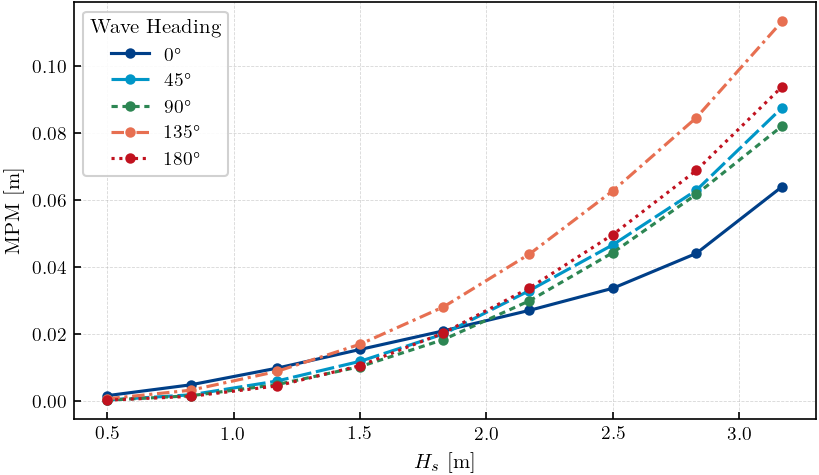

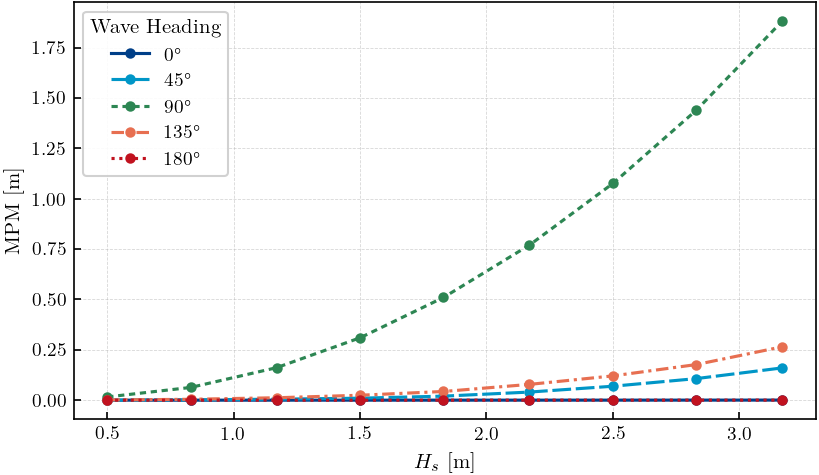

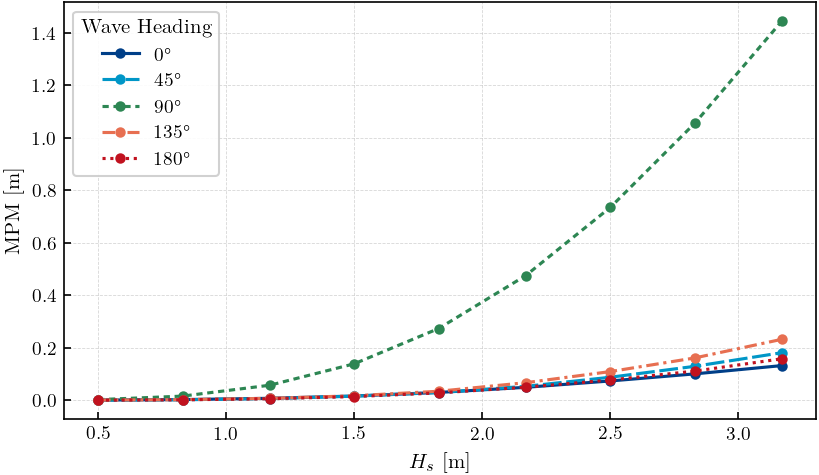

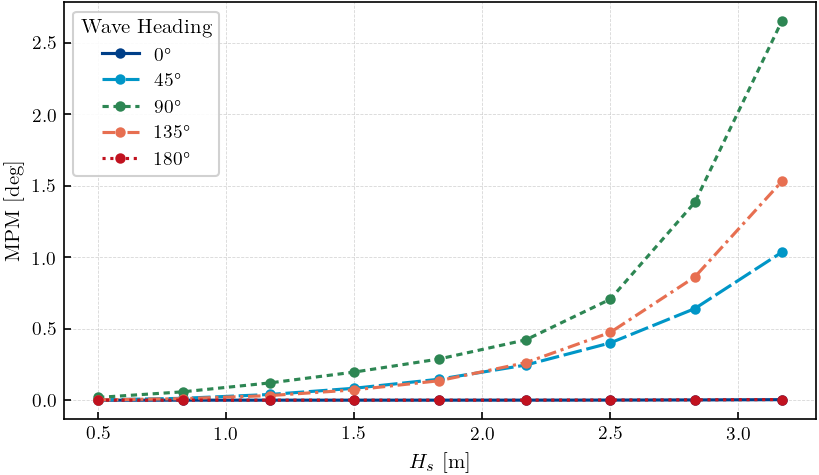

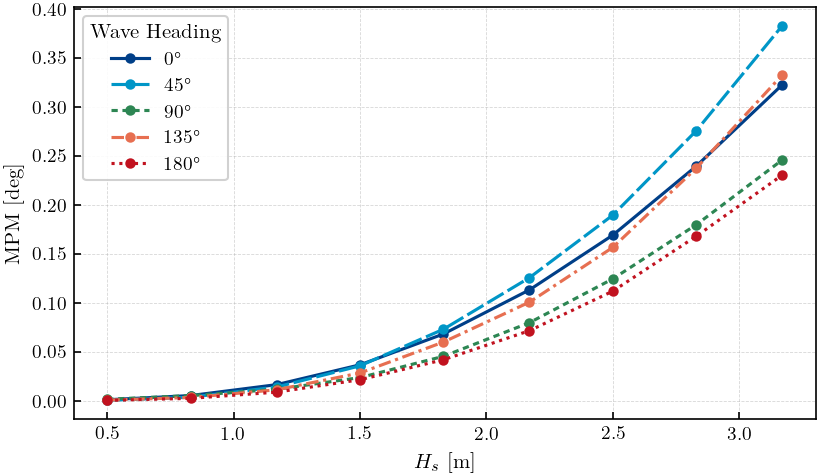

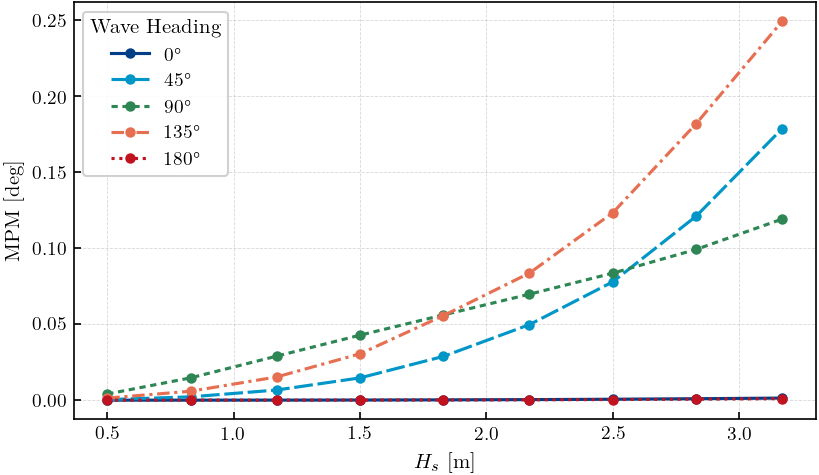

In [14]:
for j in range(6):
    fig, ax = plt.subplots(figsize=full())
    for label in results:
        ax.plot(Hs_reg, irr_mpm[label][:, j],
                color=COLORS[label], ls=LS[label], lw=1.5,
                marker="o", ms=4, label=label)
    ax.set_xlabel("$H_s$ [m]")
    ax.set_ylabel(f"MPM [{UNITS_RESP[j]}]")
    ax.legend(title="Wave Heading")
    plt.tight_layout()
    save(fig, f"mpm_response_{DOF_LABELS[j].lower()}")
    plt.show()

In [15]:
for j, dof in enumerate(DOF_LABELS):
    cols = {label: irr_mpm[label][:, j] for label in results}
    df = pd.DataFrame(cols,
                      index=pd.Index([f"{hs:.2f}" for hs in Hs_reg], name="Hs [m]"))
    df.columns.name = "Heading"
    print(f"\n{dof}  [{UNITS_RESP[j]}]  –  MPM (JONSWAP, 3-hour storm)")
    print(df.to_string(float_format="{:.4f}".format))


Surge  [m]  –  MPM (JONSWAP, 3-hour storm)
Heading     0°    45°    90°   135°   180°
Hs [m]                                    
0.50    0.0016 0.0003 0.0003 0.0007 0.0003
0.83    0.0048 0.0019 0.0016 0.0032 0.0014
1.17    0.0098 0.0060 0.0049 0.0088 0.0045
1.50    0.0154 0.0119 0.0103 0.0170 0.0106
1.83    0.0210 0.0200 0.0184 0.0281 0.0203
2.17    0.0271 0.0330 0.0299 0.0439 0.0338
2.50    0.0337 0.0467 0.0443 0.0628 0.0497
2.83    0.0441 0.0629 0.0617 0.0846 0.0688
3.17    0.0641 0.0876 0.0822 0.1134 0.0939

Sway  [m]  –  MPM (JONSWAP, 3-hour storm)
Heading     0°    45°    90°   135°   180°
Hs [m]                                    
0.50    0.0000 0.0002 0.0160 0.0010 0.0000
0.83    0.0000 0.0016 0.0632 0.0044 0.0000
1.17    0.0000 0.0049 0.1614 0.0120 0.0000
1.50    0.0000 0.0099 0.3097 0.0245 0.0000
1.83    0.0000 0.0200 0.5099 0.0432 0.0000
2.17    0.0001 0.0402 0.7699 0.0783 0.0000
2.50    0.0001 0.0692 1.0758 0.1206 0.0001
2.83    0.0002 0.1071 1.4393 0.1768 0.0001
3.17    0.